# 01 · Where does our plastic end up? From 100 bottles to a polluted planet

**Figure 1 of the article.** Millions of tonnes are hard to picture, so we shrink the world's plastic waste down to **100 bottles** and follow them.

Unlike the other figures, this one combines numbers from **three studies**. Each answers a different question:

| Step | Question | Source |
|---|---|---|
| 1 | What happens to the world's plastic waste? | Houssini, Li & Tan (2025), *Communications Earth & Environment* 6, 257. [doi.org/10.1038/s43247-025-02169-5](https://doi.org/10.1038/s43247-025-02169-5) (year 2022) |
| 2 | Of the mismanaged plastic, how much is burned in the open and how much stays behind as debris? | Cottom, Cook & Velis (2024), *Nature* 633, 101–108. [doi.org/10.1038/s41586-024-07758-6](https://doi.org/10.1038/s41586-024-07758-6) (year 2020) |
| 3 | How much reaches the ocean? | Meijer et al. (2021), *Science Advances* 7, eaaz5803. [doi.org/10.1126/sciadv.aaz5803](https://doi.org/10.1126/sciadv.aaz5803) |

⚠️ **Combining studies needs care.** They use different years, definitions and models. For example, Cottom et al. estimate 52 Mt of plastic pollution from household waste alone, while Houssini et al. count 30 Mt of mismanaged plastic in total. So from Cottom et al. we only borrow a **ratio** (burned vs. debris), not an amount. It's a simplified picture, and the notebook shows every step so you can judge it yourself.

In [1]:
# Running this in Google Colab? This cell downloads the project first. (On your own computer it does nothing.)
import os, subprocess, sys
GITHUB_REPO = "YOUR-GITHUB-USERNAME/YOUR-REPO-NAME"
ARTICLE = "weeks/20260930-where-does-plastic-end-up"
if "google.colab" in sys.modules:
    if not os.path.exists("/content/repo"):
        subprocess.run(["git", "clone", "-q", "--depth", "1", f"https://github.com/{GITHUB_REPO}", "/content/repo"], check=True)
    os.chdir(f"/content/repo/{ARTICLE}/notebooks")

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.style import COLORS, apply_style, add_title, add_footer, save_figure
from src.bottle import draw_bottle

apply_style()

## Step 1: the numbers from the literature

Every number is typed in once, with its source, and saved to `data/processed/plastic_fate_2022.csv`.

In [3]:
# Houssini et al. (2025), global plastic flows in 2022, million tonnes (Mt)
PRODUCTION_MT = 400.0
FATE_MT = {
    "Sent to recycling": 37.96,
    "Incinerated": 89.99,
    "Landfilled": 103.10,
    "Mismanaged": 29.60,
}

# Cottom et al. (2024): world plastic pollution 2020 = 22.2 Mt debris + 29.9 Mt burned in the open
# (mean values, calculated in notebook 00 from the Dryad data)
income = pd.read_csv(ROOT / "data" / "processed" / "cottom2024_income_sources.csv")
world = income[income["income_code"] == "World"].groupby("form")["tonnes"].sum()
SHARE_OPEN_BURNED = world["open burned"] / world.sum()

# Meijer et al. (2021): plastic flowing from rivers into the ocean, Mt per year
OCEAN_LOW_MT, OCEAN_HIGH_MT = 0.8, 2.7

print(f"Share of plastic pollution burned in the open (Cottom et al.): {SHARE_OPEN_BURNED:.1%}")

Share of plastic pollution burned in the open (Cottom et al.): 57.4%


In [4]:
waste_mt = sum(FATE_MT.values())
mt_per_bottle = waste_mt / 100

table = pd.DataFrame([
    {"step": 1, "item": k, "mt": v, "source": "Houssini et al. 2025"} for k, v in FATE_MT.items()
] + [
    {"step": 2, "item": "Mismanaged: burned in the open", "mt": FATE_MT["Mismanaged"] * SHARE_OPEN_BURNED,
     "source": "Houssini et al. 2025 x ratio from Cottom et al. 2024"},
    {"step": 2, "item": "Mismanaged: debris", "mt": FATE_MT["Mismanaged"] * (1 - SHARE_OPEN_BURNED),
     "source": "Houssini et al. 2025 x ratio from Cottom et al. 2024"},
    {"step": 3, "item": "Reaches the ocean (low)", "mt": OCEAN_LOW_MT, "source": "Meijer et al. 2021"},
    {"step": 3, "item": "Reaches the ocean (high)", "mt": OCEAN_HIGH_MT, "source": "Meijer et al. 2021"},
])
table["bottles_of_100"] = table["mt"] / mt_per_bottle
table["share_of_waste_pct"] = table["mt"] / waste_mt * 100
table.to_csv(ROOT / "data" / "processed" / "plastic_fate_2022.csv", index=False, float_format="%.3f")

print(f"Plastic waste with a known fate: {waste_mt:.1f} Mt  ->  1 bottle = {mt_per_bottle:.2f} Mt")
table.round(2)

Plastic waste with a known fate: 260.6 Mt  ->  1 bottle = 2.61 Mt


,step,item,mt,source,bottles_of_100,share_of_waste_pct
0,1,Sent to recycling,37.96,Houssini et al. 2025,14.56,14.56
1,1,Incinerated,89.99,Houssini et al. 2025,34.53,34.53
2,1,Landfilled,103.10,Houssini et al. 2025,39.55,39.55
3,1,Mismanaged,29.60,Houssini et al. 2025,11.36,11.36
4,2,Mismanaged: burned in the open,16.98,Houssini et al. 2025 x ratio from Cottom et al...,6.51,6.51
5,2,Mismanaged: debris,12.62,Houssini et al. 2025 x ratio from Cottom et al...,4.84,4.84
6,3,Reaches the ocean (low),0.80,Meijer et al. 2021,0.31,0.31
7,3,Reaches the ocean (high),2.70,Meijer et al. 2021,1.04,1.04


A few things worth noticing:

* **Recycling is 9% or 15%, depending on what you divide by.** 38 Mt is 9% of all plastic *produced* (400 Mt), which is the number you usually see quoted. As a share of plastic *waste* it's about 15%. Here we count waste, so it's 15 bottles.
* **Not all production becomes waste in the same year.** About a third of the plastic made each year goes into things that last: buildings, cars, furniture. That's why the waste (261 Mt) is smaller than the production (400 Mt).
* **The ocean share is small.** 0.8–2.7 Mt is **0.3–1.0%** of the waste. Most pollution never reaches the sea.

## Step 2: from tonnes to whole bottles

We can't draw 14.56 bottles. Simply rounding each number can make the total 99 or 101, so we use the **largest remainder method**: round everything down, then give the leftover bottles to the items with the largest decimals.

In [5]:
def to_whole_bottles(values, total=100):
    values = np.asarray(values, dtype=float)
    exact = values / values.sum() * total
    whole = np.floor(exact).astype(int)
    leftover = total - whole.sum()
    whole[np.argsort(exact - whole)[::-1][:leftover]] += 1
    return whole


bottles = dict(zip(FATE_MT, to_whole_bottles(list(FATE_MT.values()))))
n_mis = bottles["Mismanaged"]
n_burned = int(round(n_mis * SHARE_OPEN_BURNED))
n_debris = n_mis - n_burned
ocean_low, ocean_high = OCEAN_LOW_MT / mt_per_bottle, OCEAN_HIGH_MT / mt_per_bottle
print(bottles, f"| mismanaged -> {n_burned} burned, {n_debris} debris | ocean: {ocean_low:.1f}–{ocean_high:.1f} bottles")

{'Sent to recycling': np.int64(15), 'Incinerated': np.int64(34), 'Landfilled': np.int64(40), 'Mismanaged': np.int64(11)} | mismanaged -> 6 burned, 5 debris | ocean: 0.3–1.0 bottles


## Step 3: draw it

saved figures/fig1_where_plastic_ends_up.png (+ .svg)


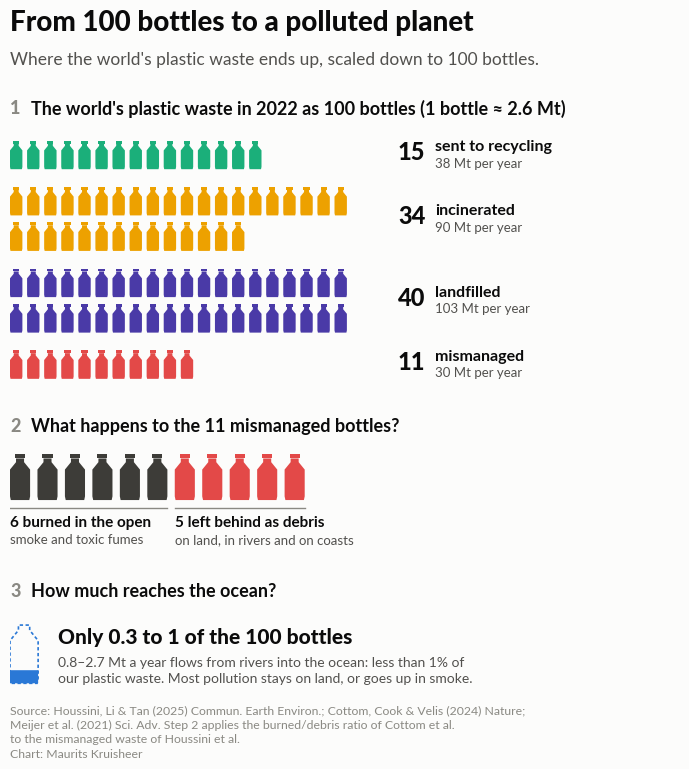

In [6]:
FATE_COLORS = {"Sent to recycling": COLORS["recycled"], "Incinerated": COLORS["incinerated"],
               "Landfilled": COLORS["landfilled"], "Mismanaged": COLORS["mismanaged"]}
FATE_TEXT = {"Sent to recycling": "sent to recycling", "Incinerated": "incinerated",
             "Landfilled": "landfilled", "Mismanaged": "mismanaged"}

# We draw in "bottle units" going down from y = 0, then size the figure to fit the content.
fig = plt.figure(figsize=(7.28, 10))
ax = fig.add_axes([0, 0, 1, 1])  # placeholder position, fixed at the end
ax.axis("off")


def step_header(y, number, text):
    ax.text(0, y, f"{number}", fontsize=13, fontweight="black", color=COLORS["ink_3"], va="top")
    ax.text(3.2, y, text, fontsize=13, fontweight="bold", va="top")


# --- 1. the 100 bottles, one block of rows per fate (20 bottles per row)
PER_ROW, W, DX, DY, GAP = 20, 1.85, 2.55, 5.3, 1.6
y = 0
step_header(y, "1", f"The world's plastic waste in 2022 as 100 bottles (1 bottle ≈ {mt_per_bottle:.1f} Mt)")
y -= 5.8
for fate, n in bottles.items():
    rows = int(np.ceil(n / PER_ROW))
    block_top = y
    for i in range(n):
        r, c = divmod(i, PER_ROW)
        draw_bottle(ax, c * DX, y - (r + 1) * DY + 0.6, W, FATE_COLORS[fate])
    mid = block_top - rows * DY / 2 + 0.3
    ax.text(62, mid + 0.2, f"{n}", fontsize=17, fontweight="black", va="center", ha="right")
    ax.text(63.5, mid + 1.1, FATE_TEXT[fate], fontsize=11.5, fontweight="bold", va="center")
    ax.text(63.5, mid - 1.4, f"{FATE_MT[fate]:.0f} Mt per year", fontsize=9.5, color=COLORS["ink_2"], va="center")
    y -= rows * DY + GAP

# --- 2. zoom in on the mismanaged bottles
y -= 3.5
step_header(y, "2", f"What happens to the {n_mis} mismanaged bottles?")
y -= 5.5
W2, DX2 = 3.0, 4.1
for i in range(n_mis):
    color = COLORS["open_burned"] if i < n_burned else COLORS["mismanaged"]
    draw_bottle(ax, i * DX2, y - 2.3 * W2, W2, color)
y_lab = y - 2.3 * W2 - 2.2
bracket = dict(color=COLORS["ink_3"], linewidth=1)
ax.plot([0, n_burned * DX2 - (DX2 - W2)], [y_lab + 1, y_lab + 1], **bracket)
ax.plot([n_burned * DX2, n_mis * DX2 - (DX2 - W2)], [y_lab + 1, y_lab + 1], **bracket)
ax.text(0, y_lab, f"{n_burned} burned in the open", fontsize=11, fontweight="bold", va="top")
ax.text(0, y_lab - 2.8, "smoke and toxic fumes", fontsize=9.5, color=COLORS["ink_2"], va="top")
ax.text(n_burned * DX2, y_lab, f"{n_debris} left behind as debris", fontsize=11, fontweight="bold", va="top")
ax.text(n_burned * DX2, y_lab - 2.8, "on land, in rivers and on coasts", fontsize=9.5, color=COLORS["ink_2"], va="top")

# --- 3. the ocean
y = y_lab - 10
step_header(y, "3", "How much reaches the ocean?")
y -= 5.5
W3 = 4.2
draw_bottle(ax, 0, y - 2.3 * W3, W3, COLORS["ocean"], fill_fraction=ocean_low,
            outline=COLORS["ocean"], lw=1.2)
ax.text(W3 + 3, y - 1.3, f"Only {ocean_low:.1f} to {ocean_high:.0f} of the 100 bottles",
        fontsize=15, fontweight="black", va="top")
ax.text(W3 + 3, y - 5.6,
        f"{OCEAN_LOW_MT}–{OCEAN_HIGH_MT} Mt a year flows from rivers into the ocean: less than 1% of\n"
        "our plastic waste. Most pollution stays on land, or goes up in smoke.",
        fontsize=10, color=COLORS["ink_2"], va="top", linespacing=1.4)
y_bottom = y - 2.3 * W3 - 1

# --- size the figure to the content: 100 units wide = 92% of the width
TOP_IN, BOTTOM_IN = 1.05, 0.85
width_in = 0.92 * fig.get_figwidth()
content_h_in = width_in * (-y_bottom + 1) / 100
fig.set_figheight(content_h_in + TOP_IN + BOTTOM_IN)
H = fig.get_figheight()
ax.set_position([0.04, BOTTOM_IN / H, 0.92, content_h_in / H])
ax.set_xlim(0, 100)
ax.set_ylim(y_bottom, 1)
ax.set_aspect("equal")

add_title(fig, "From 100 bottles to a polluted planet",
          "Where the world's plastic waste ends up, scaled down to 100 bottles.")
add_footer(fig, "Houssini, Li & Tan (2025) Commun. Earth Environ.; Cottom, Cook & Velis (2024) Nature;\n"
                "Meijer et al. (2021) Sci. Adv. Step 2 applies the burned/debris ratio of Cottom et al.\n"
                "to the mismanaged waste of Houssini et al.")
save_figure(fig, "fig1_where_plastic_ends_up")
plt.show()

## Try it yourself

* Replace the Houssini et al. numbers with the OECD *Global Plastics Outlook* (2019 data: 353 Mt waste, of which 9% recycled, 19% incinerated, 50% landfilled and 22% mismanaged). How different does the picture look?
* Change `PER_ROW` to 10 to get a classic 10 × 10 grid. Which layout is easier to read?